In [ ]:
# Import TensorFlow and other libraries#

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os
import PIL
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

import pandas as pd
import PIL
from skimage import io
from ipywidgets import interact, widgets
from IPython.display import display
#!pip install opencv-python
import cv2
#import skfuzzy as fuzz
from skimage.color import rgb2gray

In [ ]:
'''Download from the following Link'''
#data_dir = tf.keras.utils.get_file(
#    'flower_photos',
#    'https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz',
#    untar=True)

'Download from the following Link'

In [ ]:
'''OR'''

'OR'

In [ ]:
import pathlib
data_dir =r'F:/Village of Study/STAT - 811 IMAGE CLASSIFICATION/flower_photos'
data_dir = pathlib.Path(data_dir)

In [ ]:
image_count = len(list(data_dir.glob('*/*.jpg')))
print(image_count)

3670


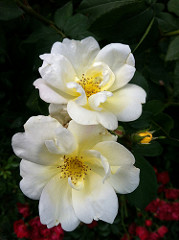

In [ ]:
roses = list(data_dir.glob('roses/*'))
PIL.Image.open(str(roses[0]))

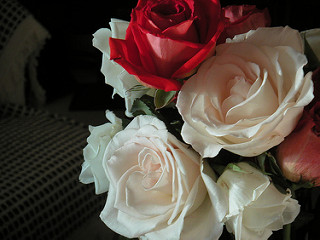

In [ ]:
PIL.Image.open(str(roses[1]))

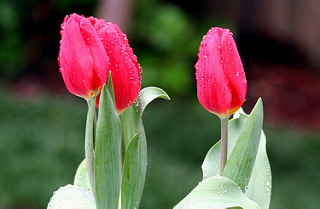

In [ ]:
tulips = list(data_dir.glob('tulips/*'))
PIL.Image.open(str(tulips[0]))

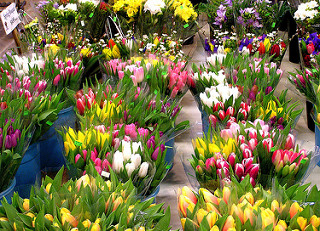

In [ ]:
PIL.Image.open(str(tulips[7]))

In [ ]:
# Create a dataset

In [ ]:
batch_size = 32
img_height = 180
img_width = 180

In [ ]:
train_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="training",
  seed=12357,
  image_size=(img_height, img_width),
  batch_size=batch_size)

Found 3670 files belonging to 5 classes.
Using 2936 files for training.


In [ ]:
val_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="validation",
  seed=12357,
  image_size=(img_height, img_width),
  batch_size=batch_size)

Found 3670 files belonging to 5 classes.
Using 734 files for validation.


In [ ]:
class_names = train_ds.class_names
print(class_names)

['Daisy', 'Dandelion', 'Roses', 'Sunflowers', 'Tulips']


In [ ]:
# Visualize the data

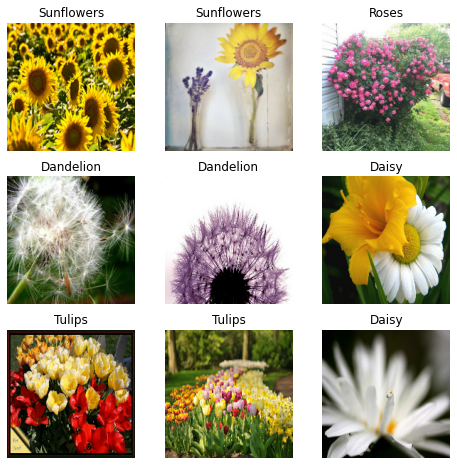

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))
for images, labels in train_ds.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

In [ ]:
for image_batch, labels_batch in train_ds:
  print(image_batch.shape)
  print(labels_batch.shape)
  break

(32, 180, 180, 3)
(32,)


In [ ]:
# Configure the dataset for performance

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [ ]:
# Standardize the data
# The RGB channel values are in the [0, 255] range.
# This is not ideal for a neural network; in general
# you should seek to make your input values small.
# Here, you will standardize values to be in
# the [0, 1] range by using tf.keras.layers.Rescaling

In [ ]:
normalization_layer = layers.Rescaling(1./255)

In [ ]:
normalized_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
image_batch, labels_batch = next(iter(normalized_ds))
first_image = image_batch[0]
# Notice the pixel values are now in `[0,1]`.
print(np.min(first_image), np.max(first_image))

0.0 1.0


In [ ]:
# Create the model

In [ ]:
num_classes = len(class_names)

model = Sequential([
  layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)),
  layers.Conv2D(16, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  layers.Dense(num_classes)
])

C:\Users\Admin\AppData\Roaming\Python\Python39\site-packages\keras\src\layers\preprocessing\tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
# Compile the model

In [ ]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

In [ ]:
# Model summary
# View all the layers of the network using the model's Model.summary method:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)              │ (None, 180, 180, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 180, 180, 16)        │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 90, 90, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 90, 90, 32)          │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 45, 45, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 45, 45, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 22, 22, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 30976)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       3,965,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 5)                   │             645 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,989,285 (15.22 MB)

 Trainable params: 3,989,285 (15.22 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
epochs=10
history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs
)

Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 29s 268ms/step - accuracy: 0.4015 - loss: 1.3773 - val_accuracy: 0.5872 - val_loss: 1.0722
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 21s 231ms/step - accuracy: 0.6370 - loss: 0.9507 - val_accuracy: 0.6635 - val_loss: 0.8416
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 23s 247ms/step - accuracy: 0.7215 - loss: 0.7385 - val_accuracy: 0.7003 - val_loss: 0.8507
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 21s 231ms/step - accuracy: 0.8228 - loss: 0.5346 - val_accuracy: 0.6812 - val_loss: 0.8236
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 25s 276ms/step - accuracy: 0.8750 - loss: 0.3657 - val_accuracy: 0.7248 - val_loss: 0.8812
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 22s 235ms/step - accuracy: 0.9468 - loss: 0.1804 - val_accuracy: 0.7112 - val_loss: 0.9318
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 22s 245ms/step - accuracy: 0.9583 - loss: 0.1473 - val_accuracy: 0.6921 - val_loss: 1.0939
Epoch 8/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 21s 233ms/step - accuracy: 0.9823 - loss: 0.0693 - val_accu

In [ ]:
# Visualize training results

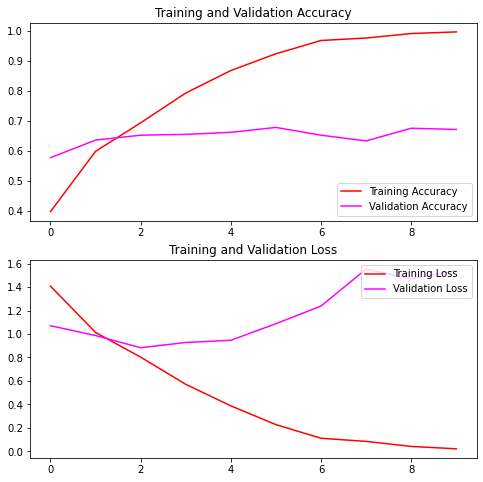

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 1)
plt.plot(epochs_range, acc, label='Training Accuracy',color='red')
plt.plot(epochs_range, val_acc, label='Validation Accuracy',color='magenta')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(2, 1, 2)
plt.plot(epochs_range, loss, label='Training Loss',color='red')
plt.plot(epochs_range, val_loss, label='Validation Loss',color='magenta')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [ ]:
'''In the plots above, the training accuracy is increasing linearly over time,
whereas validation accuracy stalls around 60% in the training process.
Also, the difference in accuracy between training and validation
accuracy is noticeable—a sign of overfitting.
When there are a small number of training examples,
the model sometimes learns from noises or unwanted details from training
examples—to an extent that it negatively impacts the performance of the model
on new examples. This phenomenon is known as overfitting. It means that the
model will have a difficult time generalizing on a new dataset.
There are multiple ways to fight overfitting in the training process.
In this tutorial, you'll use data augmentation and add Dropout to your model.'''

"In the plots above, the training accuracy is increasing linearly over time, \nwhereas validation accuracy stalls around 60% in the training process. \nAlso, the difference in accuracy between training and validation \naccuracy is noticeable—a sign of overfitting.\nWhen there are a small number of training examples, \nthe model sometimes learns from noises or unwanted details from training \nexamples—to an extent that it negatively impacts the performance of the model \non new examples. This phenomenon is known as overfitting. It means that the \nmodel will have a difficult time generalizing on a new dataset.\nThere are multiple ways to fight overfitting in the training process. \nIn this tutorial, you'll use data augmentation and add Dropout to your model."

In [ ]:
'''Data augmentation'''
'''Overfitting generally occurs when there are a small number of training examples.
Data augmentation takes the approach of generating additional training data from your
existing examples by augmenting them using random transformations that yield
believable-looking images. This helps expose the model to more aspects of the
data and generalize better.

You will implement data augmentation using the following
Keras preprocessing layers: tf.keras.layers.RandomFlip,
tf.keras.layers.RandomRotation, and tf.keras.layers.RandomZoom.
These can be included inside your model like other layers, and run on the GPU.'''

'Overfitting generally occurs when there are a small number of training examples. \nData augmentation takes the approach of generating additional training data from your\nexisting examples by augmenting them using random transformations that yield \nbelievable-looking images. This helps expose the model to more aspects of the \ndata and generalize better.\n\nYou will implement data augmentation using the following \nKeras preprocessing layers: tf.keras.layers.RandomFlip, \ntf.keras.layers.RandomRotation, and tf.keras.layers.RandomZoom. \nThese can be included inside your model like other layers, and run on the GPU.'

In [ ]:
data_augmentation = keras.Sequential(
  [
    layers.RandomFlip("horizontal",
                      input_shape=(img_height,
                                  img_width,
                                  3)),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
  ]
)

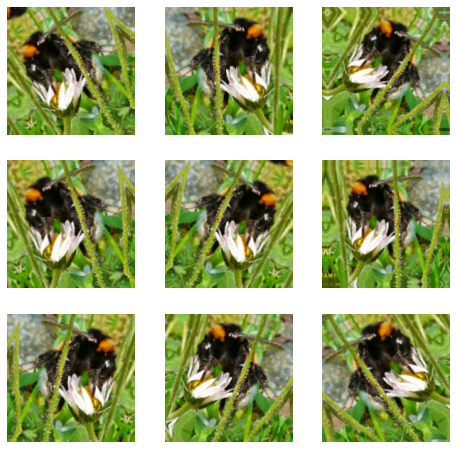

In [ ]:
plt.figure(figsize=(8, 8))
for images, _ in train_ds.take(1):
  for i in range(9):
    augmented_images = data_augmentation(images)
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(augmented_images[0].numpy().astype("uint8"))
    plt.axis("off")

In [ ]:
'''Dropout'''
'''Another technique to reduce overfitting is to introduce dropout regularization to the network.
When you apply dropout to a layer, it randomly drops out (by setting the activation to zero)
a number of output units from the layer during the training process.
Dropout takes a fractional number as its input value, in the form such as 0.1, 0.2, 0.4,
etc. This means dropping out 10%, 20% or 40% of the output units randomly from the applied layer.
Let's create a new neural network with tf.keras.layers.Dropout before training it using the augmented images:'''

"Another technique to reduce overfitting is to introduce dropout regularization to the network.\nWhen you apply dropout to a layer, it randomly drops out (by setting the activation to zero) \na number of output units from the layer during the training process. \nDropout takes a fractional number as its input value, in the form such as 0.1, 0.2, 0.4, \netc. This means dropping out 10%, 20% or 40% of the output units randomly from the applied layer.\nLet's create a new neural network with tf.keras.layers.Dropout before training it using the augmented images:"

In [ ]:
model_1 = Sequential([
  data_augmentation,
  layers.Rescaling(1./255),
  layers.Conv2D(16, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Dropout(0.2),
  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  layers.Dense(num_classes)
])

In [ ]:
# Compile and train the model
model_1.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

In [ ]:
model_1.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)            │ (None, 180, 180, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ rescaling_2 (Rescaling)              │ (None, 180, 180, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 180, 180, 16)        │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 90, 90, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 90, 90, 32)          │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 45, 45, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 45, 45, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 22, 22, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 22, 22, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 30976)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │       3,965,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 5)                   │             645 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,989,285 (15.22 MB)

 Trainable params: 3,989,285 (15.22 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
epochs = 15
history_1 = model_1.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs
)

Epoch 1/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 33s 323ms/step - accuracy: 0.3211 - loss: 1.6566 - val_accuracy: 0.5232 - val_loss: 1.1275
Epoch 2/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 27s 291ms/step - accuracy: 0.5361 - loss: 1.1370 - val_accuracy: 0.6104 - val_loss: 0.9572
Epoch 3/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 25s 277ms/step - accuracy: 0.6212 - loss: 0.9871 - val_accuracy: 0.6022 - val_loss: 1.0189
Epoch 4/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 21s 224ms/step - accuracy: 0.6291 - loss: 0.9328 - val_accuracy: 0.6076 - val_loss: 0.9260
Epoch 5/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 21s 224ms/step - accuracy: 0.6362 - loss: 0.9152 - val_accuracy: 0.6649 - val_loss: 0.8334
Epoch 6/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 21s 227ms/step - accuracy: 0.6692 - loss: 0.8336 - val_accuracy: 0.7153 - val_loss: 0.7679
Epoch 7/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 21s 224ms/step - accuracy: 0.7105 - loss: 0.7616 - val_accuracy: 0.7030 - val_loss: 0.7660
Epoch 8/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 20s 218ms/step - accuracy: 0.7096 - loss: 0.7332 - val_accu

In [ ]:
# Visualize training results

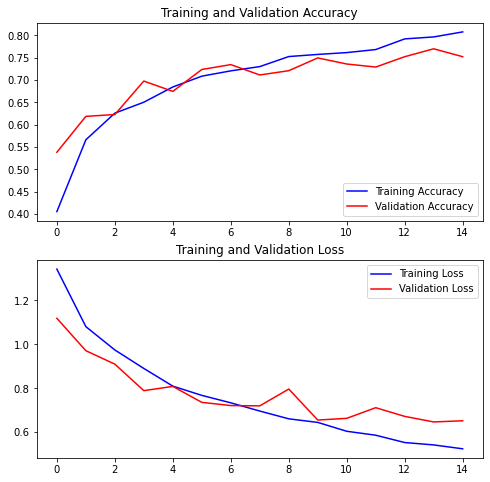

In [ ]:
acc_1 = history_1.history['accuracy']
val_acc_1 = history_1.history['val_accuracy']

loss_1 = history_1.history['loss']
val_loss_1 = history_1.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 1)
plt.plot(epochs_range, acc_1, label='Training Accuracy',color='blue')
plt.plot(epochs_range, val_acc_1, label='Validation Accuracy',color='red')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(2, 1, 2)
plt.plot(epochs_range, loss_1, label='Training Loss',color='blue')
plt.plot(epochs_range, val_loss_1, label='Validation Loss',color='red')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [ ]:
'''Predict on new data'''

'Predict on new data'

In [ ]:
sunflower_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/592px-Red_sunflower.jpg"
sunflower_path = tf.keras.utils.get_file('Red_sunflower', origin=sunflower_url)

img = tf.keras.utils.load_img(
    sunflower_path, target_size=(img_height, img_width)
)
img_array = tf.keras.utils.img_to_array(img)
img_array = tf.expand_dims(img_array, 0) # Create a batch

predictions = model.predict(img_array)
score = tf.nn.softmax(predictions[0])

print(
    "This image most likely belongs to {} with a {:.2f} percent confidence."
    .format(class_names[np.argmax(score)], 100 * np.max(score))
)

1/1 [==============================] - 0s 171ms/step
This image most likely belongs to Tulips with a 99.90 percent confidence.
